1. Setup

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

2. Load the cleaned dataset

In [4]:
df = pd.read_csv('essays_cleaned.csv')
print(f'Loaded {len(df):,} essays')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded 17,307 essays
Columns: ['essay_id', 'full_text', 'score', 'clean_text', 'word_count']


,essay_id,full_text,score,clean_text,word_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live the thing...,498
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,332
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,550


3. Build the features

All features are computed from `full_text` (the original essay). We use `full_text` instead of `clean_text` because Phase 2's cleaning removed sentence-ending punctuation, which would make sentence count meaningless.

Sentence splitting: we use a simple regex that splits on `.`, `!`, and `?`. This is fast and works well for student essays.

1. Word count: Total number of words in the essay. Straightforward measure of length.
2. Sentence count: How many sentences the essay has. Counted by splitting on periods, exclamation marks, and question marks.
3. Average sentence length: Words per sentence (word count ÷ sentence count). Tells you whether a student writes short choppy sentences or long complex ones.
4. Character count: Total number of characters, including spaces. Another length measure, but sensitive to word length (e.g., "cat" vs "elephant").
5. Word diversity: Unique words ÷ total words. A ratio from 0 to 1 that measures how much the student repeats themselves. Higher = more varied vocabulary.
6. Average word length: Average characters per word. Pulled down by common short words like "the" and "and", so it tends to sit around 4-5 for most essays.
7. Unique word count: How many distinct words the essay uses. A raw vocabulary size — bigger number means more different words.
8. Long word count: Number of words with 7 or more characters. A proxy for vocabulary sophistication — words like "education" and "significant" count, but "the" and "cat" don't.

In [10]:
def count_words(text):
    return len(str(text).split())

def count_characters(text):
    return len(str(text))

def count_sentences(text):
    # Split on . ! ? and count non-empty pieces
    pieces = [p for p in re.split(r'[.!?]+', str(text)) if p.strip()]
    return max(len(pieces), 1)   # at least 1 for a non-empty essay

def word_diversity(text):
    words = str(text).lower().split()
    if not words:
        return 0.0
    return len(set(words)) / len(words)

def count_unique_words(text):
    return len(set(str(text).lower().split()))

def average_word_length(text):
    words = str(text).split()
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

def count_long_words(text, min_length=7):
    words = str(text).split()
    return sum(1 for w in words if len(w) >= min_length)



In [6]:
# Apply each function to build the feature columns
df['word_count'] = df['full_text'].apply(count_words)
df['sentence_count'] = df['full_text'].apply(count_sentences)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']
df['char_count'] = df['full_text'].apply(count_characters)
df['word_diversity'] = df['full_text'].apply(word_diversity)
df['avg_word_length'] = df['full_text'].apply(average_word_length)
df['unique_word_count'] = df['full_text'].apply(count_unique_words)
df['long_word_count'] = df['full_text'].apply(count_long_words)

print(f'Done. Dataset now has {df.shape[1]} columns.')
df[['essay_id', 'score', 'word_count', 'sentence_count', 'avg_sentence_length','char_count', 'word_diversity', 'avg_word_length','unique_word_count', 'long_word_count']].head()

Done. Dataset now has 12 columns.


,essay_id,score,word_count,sentence_count,avg_sentence_length,char_count,word_diversity,avg_word_length,unique_word_count,long_word_count
0,000d118,3,498,13,38.307692,2677,0.487952,4.369478,243,78
1,000fe60,3,332,21,15.809524,1669,0.487952,4.018072,162,42
2,001ab80,4,550,24,22.916667,3077,0.438182,4.574545,241,103
3,001bdc0,4,451,21,21.476190,2701,0.534368,4.982262,241,133
4,002ba53,3,373,16,23.312500,2208,0.418231,4.873995,156,113


4. Summary statistics

In [7]:
feature_cols = ['word_count', 'sentence_count', 'avg_sentence_length', 'char_count','word_diversity', 'avg_word_length', 'unique_word_count', 'long_word_count']

df[feature_cols].describe().round(2)

,word_count,sentence_count,avg_sentence_length,char_count,word_diversity,avg_word_length,unique_word_count,long_word_count
count,17307.00,17307.00,17307.00,17307.00,17307.00,17307.00,17307.00,17307.00
mean,368.35,19.88,20.33,2071.62,0.51,4.54,182.71,74.78
std,150.39,8.83,13.27,925.91,0.07,0.31,61.23,39.23
min,150.00,1.00,4.88,712.00,0.05,3.44,37.00,4.00
25%,253.00,13.00,15.71,1397.00,0.46,4.32,137.00,46.00
50%,345.00,19.00,18.50,1924.00,0.51,4.53,174.00,67.00
75%,452.00,25.00,22.11,2541.00,0.56,4.75,217.00,95.00
max,1656.00,135.00,715.00,20459.00,0.77,5.88,563.00,415.00


5. Visualizing the features

Histograms — show the *shape* of each feature's distribution across all essays


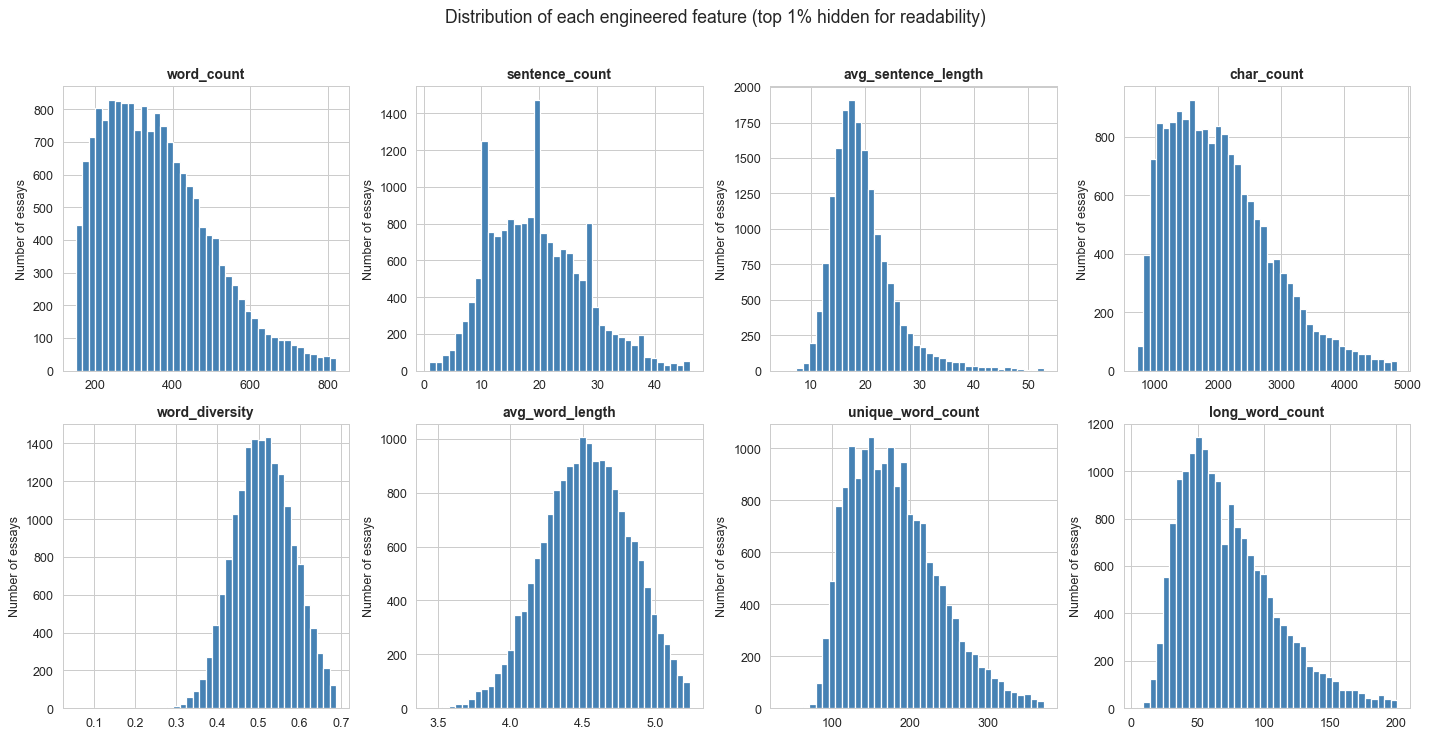

In [ ]:
# A handful of essays have almost no punctuation, one essay has 715 words and only 1 period, so its avg_sentence_length is 715. 
# These are real low-scoring essays (not data errors) but they stretch the x-axis and make the shape of the data invisible.
# We clip the view at the 99th percentile so the histogram shows where the bulk of essays actually live. 

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Keep only the bottom 99% for display — the top 1% are extreme outliers
    cutoff = df[col].quantile(0.99)
    visible = df[df[col] <= cutoff][col]

    axes[i].hist(visible, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Number of essays')

plt.suptitle('Distribution of each engineered feature (top 1% hidden for readability)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

6. Save the output

In [9]:
df.to_csv('essays_features.csv', index=False)
print(f'Saved {len(df):,} essays × {df.shape[1]} columns → essays_features.csv')

Saved 17,307 essays × 12 columns → essays_features.csv
